# Exploring microsatellite data: quality control and allele calling


Here we:
- Load relevant data
- Explore marker and sample performance
- Check the NTC for contamination, use that to set a minimum peak size threshold
- Demonstrate the peak calling algorithm

In [1]:
import os
import glob
import pandas as pd
pd.options.mode.chained_assignment = None
import numpy as np
from itertools import product
from dataclasses import dataclass

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

### Settings

In [2]:
save_results = True
output_dir = "../figures/fig2/cleaning/"
os.makedirs(output_dir, exist_ok=True)

## Available files

In [3]:
plates = ["C01", "C02"]
pools = np.arange(1, 5)

In [4]:
for plate, pool in product(plates, pools):
    dir_plate = f"../microsatdata/{plate}_pool_{pool}"
    print(plate, pool, "number of files:", len(os.listdir(dir_plate)))

C01 1 number of files: 2
C01 2 number of files: 2
C01 3 number of files: 2
C01 4 number of files: 2
C02 1 number of files: 1
C02 2 number of files: 1
C02 3 number of files: 1
C02 4 number of files: 1


## Load data

In [5]:
# Marker data
df_markers = pd.read_csv("../microsatdata/_microsats/microsat_pools.csv")

# Plate data
pos_controls = ["Dd2_10K", "Dd2_1K", "3D7_10K", "3D7_1K"]
neg_controls = ["NTC"]
controls = pos_controls + neg_controls
df_plates = pd.concat([pd.read_csv(csv, dtype={"sample_id": str}) for csv in glob.glob("../metadata/2026-01-19_design-microsat-plates/*.csv")])
df_plates = df_plates.query("sample_id not in @controls")

In [6]:
@dataclass
class Peak:
    size: float
    height: float
    area: float

In [7]:
@dataclass
class PeakStatistics:
    major_peak_size: float = None
    major_peak_height: float = None # should I rather use area?
    minor_peak_size: float = None
    minor_peak_height: float = None
    peak_ratio: float = None
    n_peaks: int = 0
    
    def __post_init__(self):
        if self.minor_peak_size is not None:
            self.peak_ratio = self.minor_peak_height / self.major_peak_height
            
    @classmethod
    def from_row(cls, row: pd.Series):
        """
        Instantiate from an ABI row
        """
        # collect them
        peaks = [Peak(size=row[f'size_{i}'], 
                      height=row[f'height_{i}'], 
                      area=row[f'peak_area_{i}'])
                 for i in np.arange(1, 10)] # max look at 10

        # filter, sort by height
        peaks = sorted(
            filter(lambda x: not pd.isna(x.size), peaks),  # could also impose threshold here
        key=lambda x: x.height, reverse=True)

        if len(peaks) == 0:
            return cls()
        if len(peaks) == 1:
            return cls(peaks[0].size, peaks[0].height, n_peaks=1)
        return cls(peaks[0].size, peaks[0].height, peaks[1].size, peaks[1].height, n_peaks=len(peaks))

In [8]:
# Peak data from ABI
dfs = []
dfsc = []
for plate, pool in product(plates, pools):
    # paths
    dir_plate = f"../microsatdata/{plate}_pool_{pool}"
    xslx = [xslx for xslx in glob.glob(f"{dir_plate}/APG26_PR*.xlsx")][0]

    # load
    df = pd.read_excel(xslx, dtype={"Sample Name": str})
    df.columns = [c.lower().replace(" ", "_") for c in df.columns]
    df.rename({"sample_name": "sample_id"}, axis=1, inplace=True)

    # trim (for now)
    df_peaks = pd.DataFrame([PeakStatistics.from_row(row)
                             for _, row in df.iterrows()])
    df_trim = pd.concat([df[df.columns[:3]], df_peaks], axis=1)
    df_trim.insert(0, "pool", pool)

    # merge markers
    df_trim = pd.merge(
        left=df_trim,
        right=df_markers,
        on=["pool", "dye"],
        how="left",
        validate="many_to_one",
    ).drop(["marker", "dye"], axis=1)

    df_control = df_trim.query("sample_id in @controls")
    df_trim = df_trim.query("sample_id not in @controls")

    # merge sample ids
    df_merge = pd.merge(
        left=df_trim,
        right=df_plates,
        on="sample_id",
        how="left",
        validate="many_to_one"
    )
    print("plate", plate, "pool", pool, "no samples", df_merge["sample_id"].unique().shape[0], "no markers", df_merge["microsat_kbp"].unique().shape[0])

    # Combine
    dfsc.append(df_control)
    dfs.append(df_merge)

plate C01 pool 1 no samples 90 no markers 2
plate C01 pool 2 no samples 90 no markers 2
plate C01 pool 3 no samples 90 no markers 2
plate C01 pool 4 no samples 90 no markers 1
plate C02 pool 1 no samples 76 no markers 2
plate C02 pool 2 no samples 76 no markers 2
plate C02 pool 3 no samples 76 no markers 2
plate C02 pool 4 no samples 76 no markers 1


### Concatenate and save

In [9]:
df_controls = pd.concat(dfsc).reset_index(drop=True)
df_comb = pd.concat(dfs).reset_index(drop=True)

In [10]:
print("Reactions")
print(f"  Controls: {df_controls.shape[0]}")
print(f"  Samples: {df_comb.shape[0]}")
print(f"  Total: {df_controls.shape[0] + df_comb.shape[0]}")
print(f"Expected Samples: {df_plates.shape[0] * 7}")

Reactions
  Controls: 84
  Samples: 1162
  Total: 1246
Expected Samples: 1162


In [11]:
if save_results:
    df_comb.to_csv(f"{output_dir}/table.microsat_data.samples.csv", index=False)
    df_controls.to_csv(f"{output_dir}/table.microsat_data.controls.csv", index=False)

##### Check negative controls for any sign of contamination

In [12]:
df_controls.query("sample_id == 'NTC'")

,pool,sample_id,major_peak_size,major_peak_height,minor_peak_size,minor_peak_height,peak_ratio,n_peaks,microsat_kbp,fluorophore,product_bp
4,1,NTC,NaN,NaN,NaN,NaN,NaN,0,-0.15,FAM,225
5,1,NTC,NaN,NaN,NaN,NaN,NaN,0,-0.15,FAM,225
10,1,NTC,NaN,NaN,NaN,NaN,NaN,0,15.00,HEX,150
11,1,NTC,NaN,NaN,NaN,NaN,NaN,0,15.00,HEX,150
16,2,NTC,NaN,NaN,NaN,NaN,NaN,0,-31.90,FAM,209
17,2,NTC,NaN,NaN,NaN,NaN,NaN,0,-31.90,FAM,209
22,2,NTC,NaN,NaN,NaN,NaN,NaN,0,72.30,HEX,240
23,2,NTC,NaN,NaN,NaN,NaN,NaN,0,72.30,HEX,240
28,3,NTC,NaN,NaN,NaN,NaN,NaN,0,-3.70,FAM,164
29,3,NTC,NaN,NaN,NaN,NaN,NaN,0,-3.70,FAM,164


- No sign of contamination at all
- For me, this suggests it is **not** justified to remove small peaks (e.g. with low height) that have been called by GeneMapper

In [13]:
df_poscontrols = df_controls.query("sample_id in @pos_controls")
df_poscontrols["strains"] = [s.split("_")[0] for s in df_poscontrols["sample_id"]]

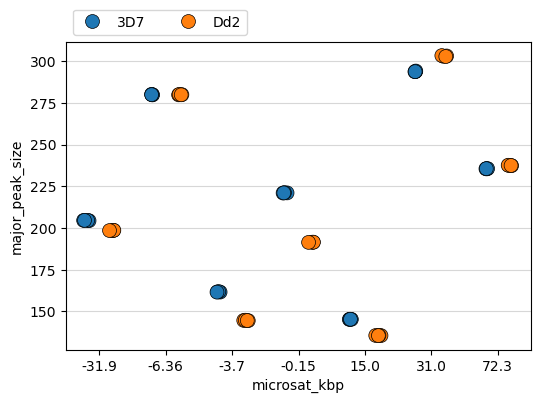

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

sns.stripplot(
    x="microsat_kbp",
    y="major_peak_size",
    hue="strains",
    edgecolor='black', linewidth=0.5, s=10,
    dodge=True,
    data=df_poscontrols
)
ax.legend(bbox_to_anchor=(0, 1), loc="lower left", ncol=2)
ax.grid(axis='y', alpha=0.5)

- You can see the peak calls are very consistent for positive controls

### Peak height distribution

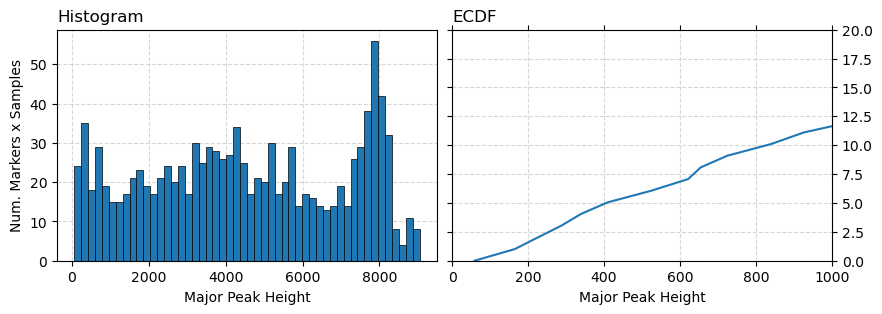

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharex=False)
fig.subplots_adjust(wspace=0.04)

ax = axes[0]
ax.hist(df_comb["major_peak_height"], bins=50, ec='black', lw=0.5)
ax.set_xlabel("Major Peak Height")
ax.set_ylabel("Num. Markers x Samples")
ax.set_axisbelow(True)
ax.grid(ls='dashed', alpha=0.5)
ax.set_title("Histogram", loc="left")

ax = axes[1]
df_quants = df_comb["major_peak_height"].quantile(np.linspace(0, 1, 100))
ax.plot(df_quants.values, 100*df_quants.index)
ax.set_xlim(0, 1_000)
ax.set_ylim(0, 20)
ax.set_xlabel("Major Peak Height")
ax.tick_params(labelright=True, labelleft=False, tick2On=True)
ax.set_axisbelow(True)
ax.grid(ls='dashed', alpha=0.5)
ax.set_title("ECDF", loc="left")

if save_results:
    fig.savefig(f"{output_dir}/plot.peak_heights.png", dpi=300, pad_inches=0.5, bbox_inches="tight")

- There actually *is not* a particularly big spike near zero, that might suggest spurious calls caused by primers etc.
- This further supports the idea that we should not trim peaks

### Summaries

In [16]:
print(f"Number of samples in plates: {df_plates.sample_id.unique().shape[0]}")
print(f"Number of samples in microsat data: {df_comb.sample_id.unique().shape[0]}")

Number of samples in plates: 166
Number of samples in microsat data: 166


In [17]:
pd.crosstab(
    df_plates["carrier_A724E"],
    df_plates["province"],
    margins='All'
)

province,eastern,muchinga,northwestern,western,All
carrier_A724E,,,,,
False,30,2,33,46,111
True,0,1,26,28,55
All,30,3,59,74,166


- Here is a look at the overall content of the dataset
- I have a good balance in both Northwestern and Western of samples carrying A724E -- so I could calculating heterozygosity by province

##### Marker Performance

In [18]:
summary_markers = pd.concat(
    [pd.crosstab(df_comb["microsat_kbp"],
                 df_comb["n_peaks"],
                 dropna=False),
     df_comb.groupby("microsat_kbp").agg(
        per_failed=pd.NamedAgg("n_peaks", lambda x: round(100*sum(x == 0)/len(x), 2)),
        per_single=pd.NamedAgg("n_peaks", lambda x: round(100*sum(x == 1)/len(x), 2)),
        per_multi=pd.NamedAgg("n_peaks", lambda x: round(100*sum(x > 1)/len(x), 2))),
     df_comb.groupby("microsat_kbp").agg(mean_peak_height=pd.NamedAgg("major_peak_height", "mean")),
     df_comb.query("n_peaks >= 2").groupby("microsat_kbp").agg(
        peak_ratio_mean=pd.NamedAgg("peak_ratio", "mean"),
        peak_ratio_med=pd.NamedAgg("peak_ratio", "median"))],
    axis=1
)
if save_results:
    summary_markers.to_csv(f"{output_dir}/summary.microsat_performance.csv", index=True)
summary_markers

,0,1,2,3,4,per_failed,per_single,per_multi,mean_peak_height,peak_ratio_mean,peak_ratio_med
microsat_kbp,,,,,,,,,,,
-31.90,8,148,10,0,0,4.82,89.16,6.02,3963.518987,0.563055,0.554346
-6.36,9,153,4,0,0,5.42,92.17,2.41,6511.044586,0.561084,0.597471
-3.70,5,148,9,3,1,3.01,89.16,7.83,4603.795031,0.252394,0.223320
-0.15,3,127,35,1,0,1.81,76.51,21.69,5434.650307,0.226076,0.206667
15.00,7,94,63,2,0,4.22,56.63,39.16,4579.232704,0.395055,0.380165
31.00,18,145,3,0,0,10.84,87.35,1.81,3018.425676,0.667640,0.838710
72.30,1,151,14,0,0,0.60,90.96,8.43,3423.569697,0.527765,0.522320


**Conclusions**
- 31kbp has the most samples (18) with no peaks identified; this is an 10.8% failure rate
- 15kbp has the most with multiple peaks (65)
- Both -0.15kbp and 15kbp have lots of multiple peaks, but the peak ratios are low (<0.4) suggesting stutter peaks are the cause
- However there is some evidence of potential genuine second peaks, e.g. polyclonals

**Exploring peak size outliers**
- I know from prior data exploration, for two markers we have a small number of samples with outlier sizes (e.g. >100bp different from others)
- From the gel, there is evidence that these peaks are due to off-target amplification

In [19]:
df_outliers = df_comb.query(
    "(microsat_kbp == 15.0 and major_peak_size > 300) or "
    "(microsat_kbp == 31.0 and major_peak_size < 220)"
)

In [20]:
df_outliers

,pool,sample_id,major_peak_size,major_peak_height,minor_peak_size,minor_peak_height,peak_ratio,n_peaks,microsat_kbp,fluorophore,product_bp,plate,well,extraction_id,set_type,district,province,carrier_A724E
724,1,1046736,310.20,423.0,135.4,361.0,0.853428,2,15.0,HEX,150,C02,B7,Z238,representative,luampa,western,False
731,1,5053708,310.17,321.0,NaN,NaN,NaN,1,15.0,HEX,150,C02,D9,Z264,representative,sikongo,western,True
740,1,8010689,310.36,284.0,138.7,141.0,0.496479,2,15.0,HEX,150,C02,H1,Z152,representative,chipata,eastern,False
756,1,8021948,310.24,615.0,NaN,NaN,NaN,1,15.0,HEX,150,C02,E4,Z190,representative,kaoma,western,False
757,1,8021950,310.14,704.0,NaN,NaN,NaN,1,15.0,HEX,150,C02,B4,Z186,clonal,kaoma,western,False
760,1,8023249,310.21,658.0,NaN,NaN,NaN,1,15.0,HEX,150,C02,D3,Z172,representative,solwezi,northwestern,False
761,1,8023285,310.20,648.0,135.4,241.0,0.371914,2,15.0,HEX,150,C02,C3,Z171,representative,solwezi,northwestern,False
1064,3,8023249,210.17,890.0,NaN,NaN,NaN,1,31.0,HEX,300,C02,D3,Z172,representative,solwezi,northwestern,False
1065,3,8023285,210.04,1102.0,302.8,288.0,0.261343,2,31.0,HEX,300,C02,C3,Z171,representative,solwezi,northwestern,False


In [21]:
df_comb["likely_artefact"] = (
    ((df_comb["microsat_kbp"] == 15.0) & (df_comb["major_peak_size"] > 300)) |
    ((df_comb["microsat_kbp"] == 31.0) & (df_comb["major_peak_size"] < 220))
)
# Switch to minor peak, if it exists, or set to zero for easiest

In [22]:
for ix, row in df_comb.iterrows():
    if not row["likely_artefact"]:
        continue
    if row["n_peaks"] == 1:
        df_comb.loc[ix, "n_peaks"] = 0 # erase peak
    else:    
        df_comb.loc[ix, "major_peak_size"] = row["minor_peak_size"] # overwrite
        df_comb.loc[ix, "major_peak_height"] = row["minor_peak_height"]

In [23]:
df_comb.query("likely_artefact") # fixed

,pool,sample_id,major_peak_size,major_peak_height,minor_peak_size,minor_peak_height,peak_ratio,n_peaks,microsat_kbp,fluorophore,product_bp,plate,well,extraction_id,set_type,district,province,carrier_A724E,likely_artefact
724,1,1046736,135.40,361.0,135.4,361.0,0.853428,2,15.0,HEX,150,C02,B7,Z238,representative,luampa,western,False,True
731,1,5053708,310.17,321.0,NaN,NaN,NaN,0,15.0,HEX,150,C02,D9,Z264,representative,sikongo,western,True,True
740,1,8010689,138.70,141.0,138.7,141.0,0.496479,2,15.0,HEX,150,C02,H1,Z152,representative,chipata,eastern,False,True
756,1,8021948,310.24,615.0,NaN,NaN,NaN,0,15.0,HEX,150,C02,E4,Z190,representative,kaoma,western,False,True
757,1,8021950,310.14,704.0,NaN,NaN,NaN,0,15.0,HEX,150,C02,B4,Z186,clonal,kaoma,western,False,True
760,1,8023249,310.21,658.0,NaN,NaN,NaN,0,15.0,HEX,150,C02,D3,Z172,representative,solwezi,northwestern,False,True
761,1,8023285,135.40,241.0,135.4,241.0,0.371914,2,15.0,HEX,150,C02,C3,Z171,representative,solwezi,northwestern,False,True
1064,3,8023249,210.17,890.0,NaN,NaN,NaN,0,31.0,HEX,300,C02,D3,Z172,representative,solwezi,northwestern,False,True
1065,3,8023285,302.80,288.0,302.8,288.0,0.261343,2,31.0,HEX,300,C02,C3,Z171,representative,solwezi,northwestern,False,True


- In practice, what we are doing is ignoring any artefactual peaks caused by offtarget amplification

##### Sample Performance

In [24]:
df_samples = (df_comb.groupby(["sample_id", "province", "district", "carrier_A724E"]).agg(
    markers_failed=pd.NamedAgg("n_peaks", lambda x: sum(x == 0)), # failed
    markers_passed=pd.NamedAgg("n_peaks", lambda x: sum(x > 0)), # passed
    markers_single_peak=pd.NamedAgg("n_peaks", lambda x: sum(x == 1)),
    markers_multiple_peaks=pd.NamedAgg("n_peaks", lambda x: sum(x > 1)), # candidate polyclonal
).reset_index())

In [25]:
df_samples.head()

,sample_id,province,district,carrier_A724E,markers_failed,markers_passed,markers_single_peak,markers_multiple_peaks
0,1012412,northwestern,zambezi,True,0,7,6,1
1,1012423,northwestern,mufumbwe,False,0,7,6,1
2,1012426,northwestern,mufumbwe,True,0,7,7,0
3,1012427,northwestern,mufumbwe,False,0,7,6,1
4,1012431,northwestern,mufumbwe,False,0,7,6,1


In [26]:
pd.crosstab(
    [df_samples["province"]],
    df_samples["markers_passed"],
    margins='All'
) # lost some in western province

markers_passed,1,2,3,4,5,6,7,All
province,,,,,,,,
eastern,0,1,0,1,2,1,25,30
muchinga,0,0,0,0,0,1,2,3
northwestern,0,0,1,1,1,3,53,59
western,1,1,4,1,0,0,67,74
All,1,2,5,3,3,5,147,166


In [27]:
df_samples["passed"] = df_samples["markers_passed"] >= 7 # to avoid dealing with missing data, perhaps this?

In [28]:
p, n = df_samples['passed'].sum(), df_samples.shape[0]
print(f"Of {n} samples processed overall, {p} ({p/n*100:.2f}%) passed.")
p, n = df_samples.query("province != 'eastern'")['passed'].sum(), df_samples.query("province != 'eastern'").shape[0]
print(f"Of {n} samples processed excluding Eastern province, {p} ({p/n*100:.2f}%) passed.")

Of 166 samples processed overall, 147 (88.55%) passed.
Of 136 samples processed excluding Eastern province, 122 (89.71%) passed.


In [29]:
pd.crosstab(
    df_samples["province"],
    df_samples["passed"],
    margins='All'
)

passed,False,True,All
province,,,
eastern,5,25,30
muchinga,1,2,3
northwestern,6,53,59
western,7,67,74
All,19,147,166


In [30]:
pd.crosstab(
    df_samples["carrier_A724E"],
    df_samples["passed"],
    margins='All'
)

passed,False,True,All
carrier_A724E,,,
False,12,99,111
True,7,48,55
All,19,147,166


In [31]:
df_samples_passed = df_samples.query("passed")

In [32]:
pd.crosstab(
    df_samples_passed["province"],
    df_samples_passed["carrier_A724E"],
    margins='All'
)

carrier_A724E,False,True,All
province,,,
eastern,25,0,25
muchinga,1,1,2
northwestern,31,22,53
western,42,25,67
All,99,48,147


- Minus the eastern province samples, this would be the final analysis set

In [33]:
pd.crosstab(
    df_samples_passed.query("province != 'eastern'")["province"],
    df_samples_passed.query("province != 'eastern'")["carrier_A724E"],
    margins='All'
)

carrier_A724E,False,True,All
province,,,
muchinga,1,1,2
northwestern,31,22,53
western,42,25,67
All,74,48,122


**So final dataset for analysis should include:**
- 122 samples
- 67 western, 53 northwestern, 2 muchinga
- 74 without A724E, 48 with A724E

In [34]:
if save_results:
    df_samples.to_csv(f"{output_dir}/summary.sample_performance.csv", index=False)
    #summary_samples.to_csv(f"{output_dir}/summary.sample_performance.csv", index=True)

### Sample filtering for analysis

**Filter out Eastern province, does not look interesting -- better focus on A724E**

In [35]:
# Filter out eastern province, since not interesting
passing_samples = df_samples.query("passed").sample_id.tolist() # these have all 7 markers successfully amplified
df_west = df_comb.query("sample_id in @passing_samples and province != 'eastern'")

In [36]:
df_comb.shape[0]/7, df_west.shape[0]/7 # looks correct

(166.0, 122.0)

**Filter out potentially duplicated samples based on AMA1**

In [37]:
df_dups = pd.read_csv("../metadata/2026-04-05_sample-duplication/table.removed_duplicates.csv", dtype={"sample_id": str})

In [38]:
set(df_west.sample_id).intersection(df_dups.sample_id)

set()

- There were none -- this is because I already removed the duplicated district; and most samples duplicated are not in western or northwestern

### Exploring peak sizes
From now forward, we will remove the Eastern Province samples, as they are not relevant for this analysis in my view; since there is no A724E there.

In [39]:
df_west.major_peak_size.describe() # no missing data

count    854.000000
mean     213.366464
std       54.741860
min      129.130000
25%      153.230000
50%      212.320000
75%      255.687500
max      330.840000
Name: major_peak_size, dtype: float64

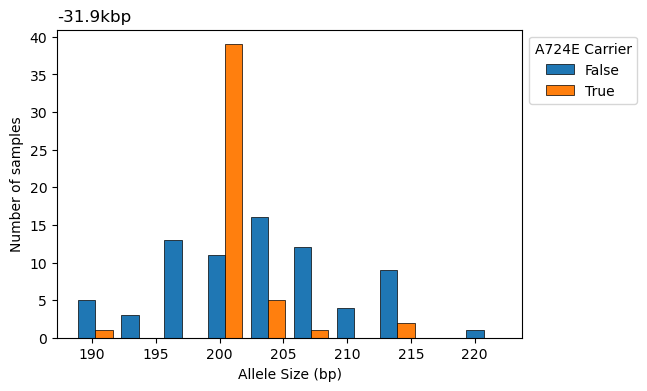

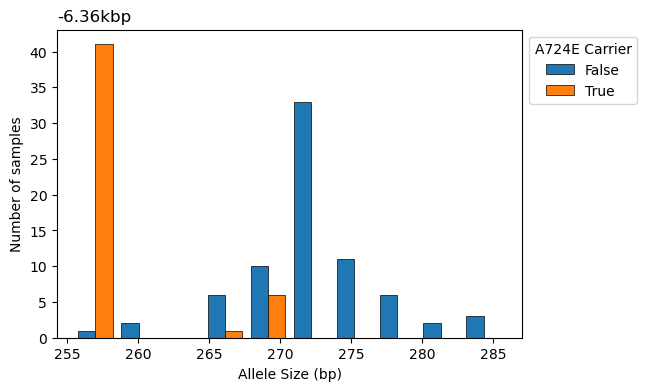

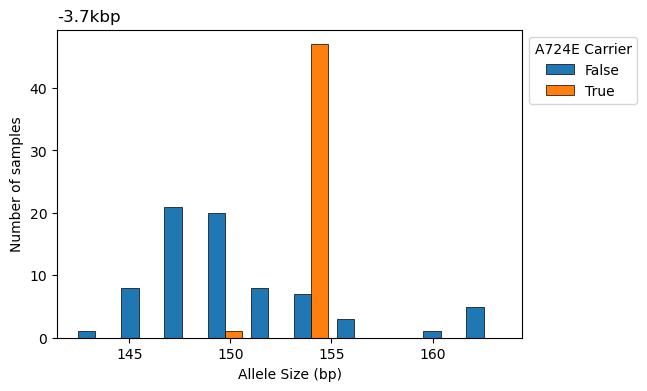

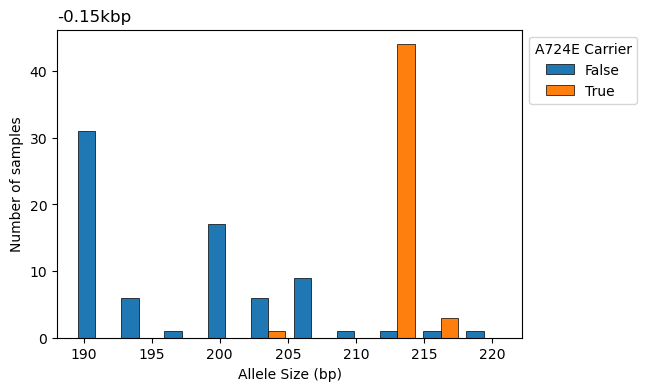

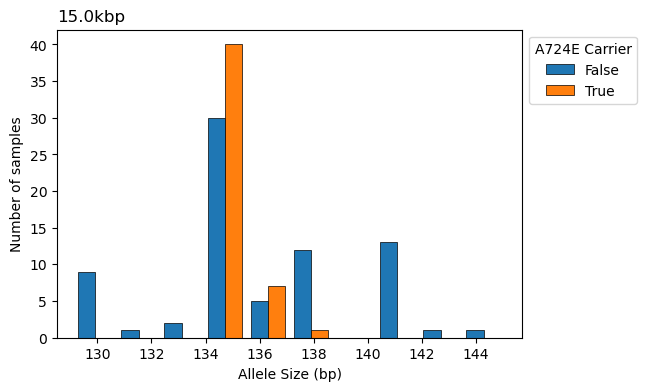

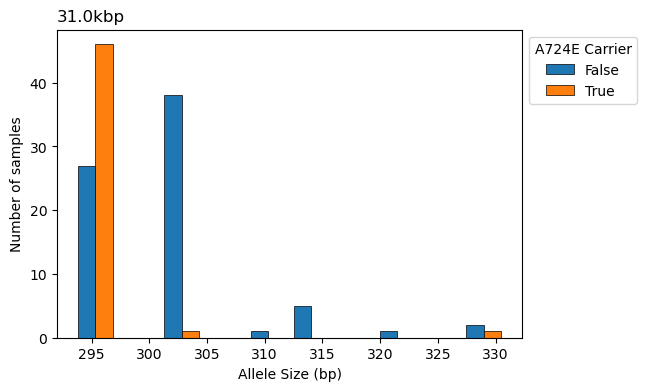

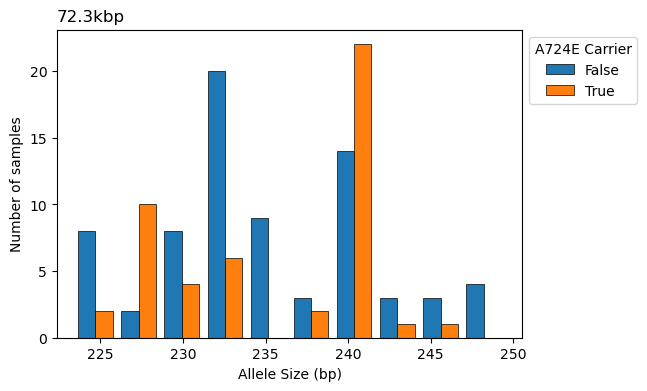

In [40]:
for micro, dfm in df_west.groupby("microsat_kbp"):

    # group by genotype
    grps = dfm.groupby("carrier_A724E")
    
    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    
    ax.hist([dfg["major_peak_size"] for g, dfg in grps],
            ec='black', lw=0.5,
            label=[g for g, dfg in grps])
    
    ax.set_title(f"{micro}kbp", loc="left")
    ax.set_xlabel("Allele Size (bp)")
    ax.set_ylabel("Number of samples")
    
    ax.legend(bbox_to_anchor=(1, 1), loc="upper left", title="A724E Carrier")

    if save_results:
        os.makedirs(f"{output_dir}/peak_sizes", exist_ok=True)
        fig.savefig(f"{output_dir}/peak_sizes/plot.{str(micro)}kbp.png", dpi=300, bbox_inches="tight", pad_inches=0.5)

### Allele calling

In [41]:
# Get repeat unit numbers
df_repeats = pd.read_csv("../microsatdata/_microsats/microsat_repeats.csv")
df_repeats.index = df_repeats['microsat_kbp']

# Define a list of loci for convenience
loci = df_comb["microsat_kbp"].unique().tolist()

In [42]:
def get_alleles(df_locus, unit_bp: int):
    min_peak, max_peak = df_locus["major_peak_size"].describe()[['min', 'max']]
    mode_allele = df_locus["major_peak_size"].round().mode().iloc[0]
    alleles = [mode_allele]
    while alleles[-1] >= min_peak:
        alleles.append(alleles[-1] - unit_bp)
    alleles = alleles[::-1]
    while alleles[-1] <= max_peak:
        alleles.append(alleles[-1] + unit_bp)
    print(f"Have {len(alleles)} expected alleles from {alleles[0]} to {alleles[-1]}.")

    return alleles

In [43]:
def call_alleles(df_locus, unit_bp: int):
    alleles = get_alleles(df_locus, unit_bp)
    peaks = df_locus["major_peak_size"].to_numpy()
    peak_diffs = peaks[:,np.newaxis] - np.array(alleles)
    return np.array(alleles)[np.abs(peak_diffs).argmin(1)]

## Call alleles

In [44]:
dfs = []
for locus in loci:
    df_locus = df_west.query("microsat_kbp == @locus")
    df_locus["allele_size"] = call_alleles(df_locus, unit_bp=df_repeats.loc[locus]["unit_bp"])
    dfs.append(df_locus)

Have 17 expected alleles from 189.0 to 221.0.
Have 7 expected alleles from 129.0 to 147.0.
Have 19 expected alleles from 188.0 to 224.0.
Have 15 expected alleles from 223.0 to 251.0.
Have 13 expected alleles from 141.0 to 165.0.
Have 7 expected alleles from 285.0 to 339.0.
Have 12 expected alleles from 253.0 to 286.0.


In [45]:
df_west = pd.concat(dfs) # OVERWRITTEN!

**Visualise calling**

Have 17 expected alleles from 189.0 to 221.0.
Have 7 expected alleles from 129.0 to 147.0.
Have 19 expected alleles from 188.0 to 224.0.
Have 15 expected alleles from 223.0 to 251.0.
Have 13 expected alleles from 141.0 to 165.0.
Have 7 expected alleles from 285.0 to 339.0.
Have 12 expected alleles from 253.0 to 286.0.


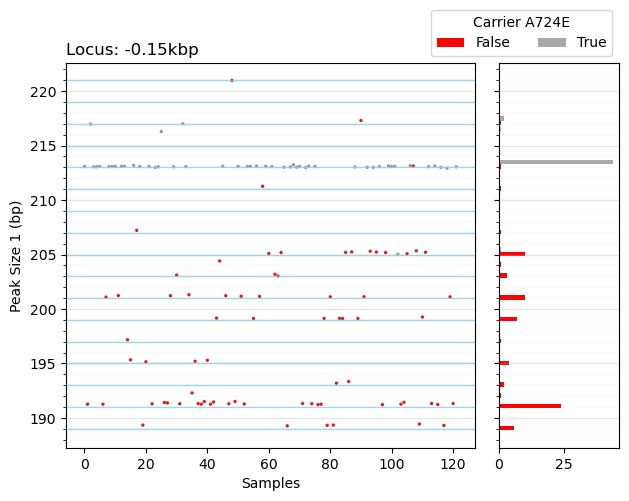

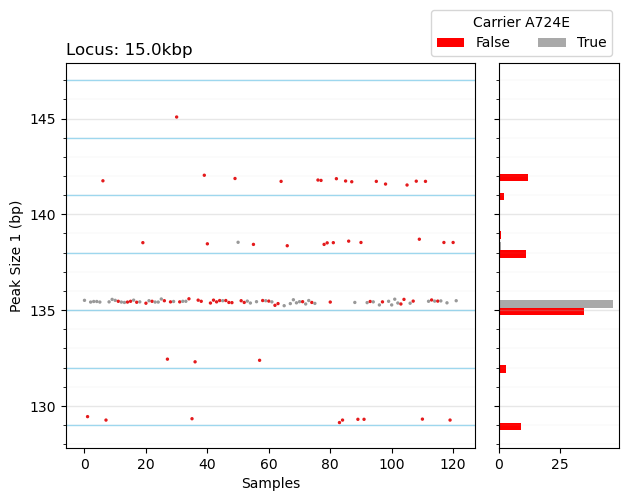

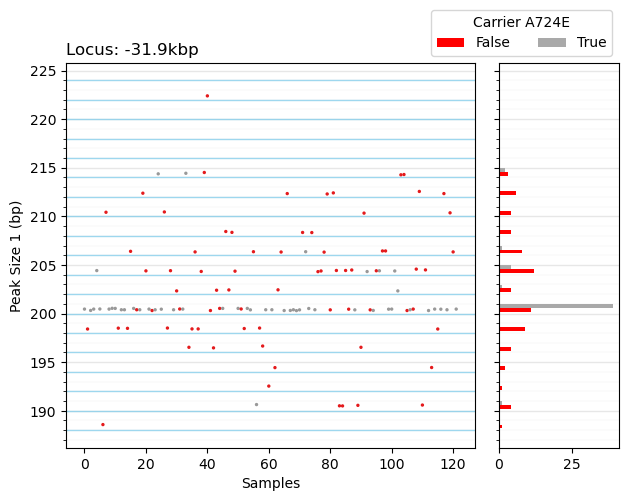

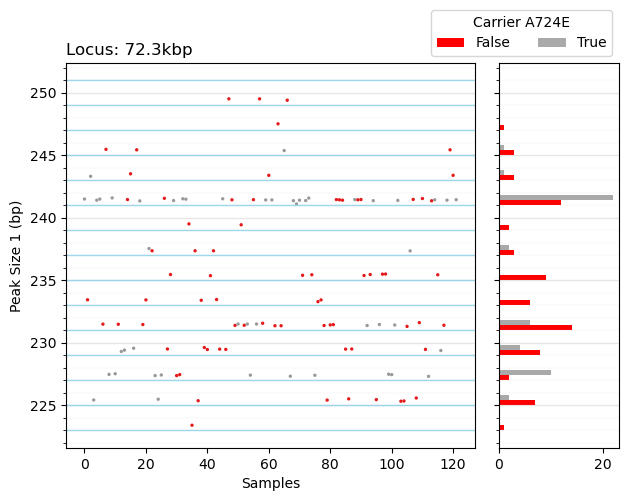

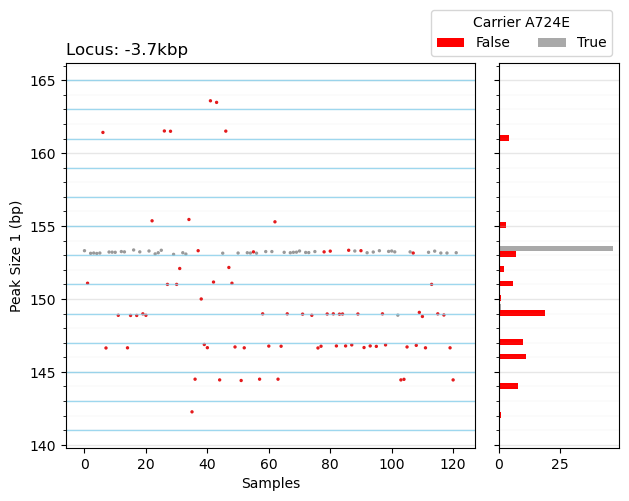

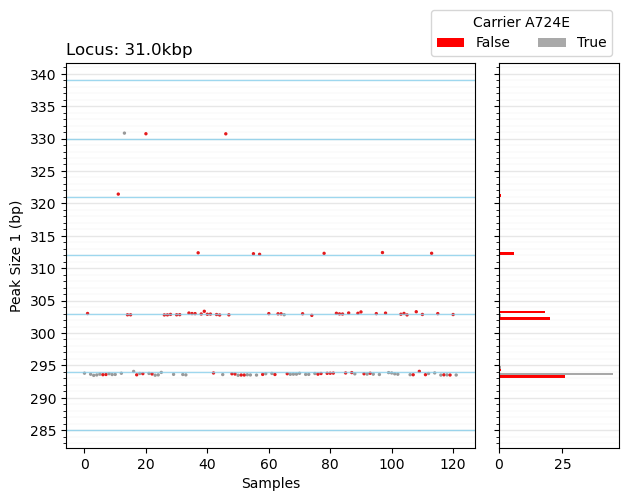

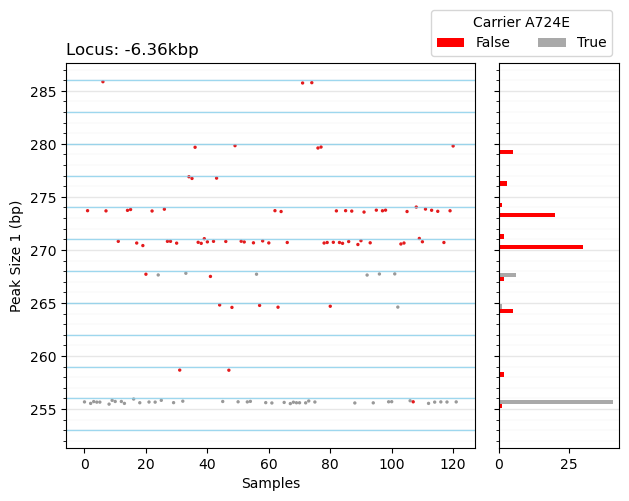

In [46]:
for locus in loci:
    
    fig = plt.figure(figsize=(9, 5))
    fig.subplots_adjust(wspace=0.2)
    
    # Figure
    gs = GridSpec(nrows=1, ncols=5)
    axs = plt.subplot(gs[:,1:4])
    axh = plt.subplot(gs[:,4:], sharey=axs)
    
    # Scatterplot
    df_locus = df_west.query("microsat_kbp == @locus")
    df_locus = df_locus.sort_values(['province', 'district'])

    # Get alleles
    alleles = get_alleles(df_locus, unit_bp=df_repeats.loc[locus]["unit_bp"])
    

    # Scatter
    axs.scatter(
        x=range(df_locus.shape[0]),
        y=df_locus['major_peak_size'],
        c=df_locus['carrier_A724E'],
        cmap='Set1',
        s=2
    )
    axs.set_axisbelow(True)
    axs.yaxis.set_minor_locator(plt.MultipleLocator(1))
    axs.yaxis.set_major_locator(plt.MultipleLocator(5))
    axs.grid(axis='y', which='minor', lw=0.2, alpha=0.3)
    axs.grid(axis='y', which='major', lw=1.0, alpha=0.3)
    axs.set_ylabel("Peak Size 1 (bp)")
    axs.set_xlabel("Samples")
    axs.set_title(f"Locus: {locus}kbp", loc='left')
    for allele in alleles:
        axs.axhline(allele, lw=1, color='skyblue', alpha=0.8)
    
    # Histogram
    grps = df_locus.groupby('carrier_A724E')
    h = axh.hist(
        [gdf['major_peak_size'] for _, gdf in grps],
        label=[g for g, _ in grps],
        bins=np.arange(df_locus['major_peak_size'].min(), df_locus['major_peak_size'].max()) - 0.5,
        orientation='horizontal',
        align='mid',
        color=['red', 'darkgrey']
    )
    axh.tick_params(labelleft=False)
    axh.grid(axis='y', which='minor', lw=0.2, alpha=0.3)
    axh.grid(axis='y', which='major', lw=1.0, alpha=0.3)
    axh.legend(loc="lower right", bbox_to_anchor=(1, 1), ncols=2, title="Carrier A724E")
    
    if save_results:
        os.makedirs(f"{output_dir}/allele_sizes/", exist_ok=True)
        fig.savefig(f"{output_dir}/allele_sizes/plot.{str(locus)}kbp.png", dpi=300, pad_inches=0.5)

- you can see dye shifting, but the markers are always closest to the correct allele, so the shifting does not affect output.

### Write analysis files

In [47]:
keep_columns = [
    "pool", "microsat_kbp", "fluorophore", "plate", "well", 
    "major_peak_size", "major_peak_height", "minor_peak_size", "minor_peak_height", "n_peaks",
    "allele_size",
    "sample_id", "extraction_id", "set_type", "province", "district", "carrier_A724E"
]

In [48]:
df_west[keep_columns]

,pool,microsat_kbp,fluorophore,plate,well,major_peak_size,major_peak_height,minor_peak_size,minor_peak_height,n_peaks,allele_size,sample_id,extraction_id,set_type,province,district,carrier_A724E
0,1,-0.15,FAM,C01,H2,216.30,5916.0,NaN,NaN,1,217.0,1012426,Z018,representative,northwestern,mufumbwe,True
1,1,-0.15,FAM,C01,D12,220.98,2934.0,223.01,898.0,2,221.0,1012521,Z144,clonal,northwestern,zambezi,False
2,1,-0.15,FAM,C01,B2,191.51,7849.0,NaN,NaN,1,191.0,1012556,Z008,clonal,northwestern,zambezi,False
3,1,-0.15,FAM,C01,D5,213.01,6614.0,215.03,1104.0,2,213.0,1046675,Z058,representative,western,luampa,True
4,1,-0.15,FAM,C01,G5,189.27,7823.0,NaN,NaN,1,189.0,1046677,Z061,clonal,western,luampa,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1153,4,-6.36,FAM,C02,H5,255.71,7836.0,NaN,NaN,1,256.0,8023440,Z218,representative,northwestern,kabompo,True
1154,4,-6.36,FAM,C02,D4,270.81,1504.0,NaN,NaN,1,271.0,8023441,Z188,representative,northwestern,kabompo,False
1155,4,-6.36,FAM,C02,C10,270.65,8136.0,NaN,NaN,1,271.0,8023974,Z279,representative,northwestern,kasempa,False
1160,4,-6.36,FAM,C02,G6,270.77,7406.0,NaN,NaN,1,271.0,8034013,Z231,representative,western,sesheke,False


In [49]:
if save_results:
    df_west[keep_columns].to_csv(f"{output_dir}/table.microsat_data.alleles_called.no_eastern.csv", index=False)